# Phase 1: Full Rubric Notebook (Single File, Multi-Cell)

This notebook is self-contained and split into clear sections so it is easy to run, explain, and present.


## Setup and Imports
- Import all required libraries and configure plotting behavior for this run.


Human comment: run this setup cell first whenever you reopen Colab so imports and constants are ready.


In [16]:
"""
Phase 1 Soft Computing Pipeline (Rubric-Aligned)

This script is aligned to the "Math for Data Science Project Tasks Cover Sheet"
requirements and keeps the project in a flat structure.

Rubric-oriented coverage in this file:
1) Preprocessing
   - Data visualization
   - Missing values treatment
   - Binning process
   - Descriptive statistics (min/max/mean/variance/std/skewness/kurtosis)
   - Covariance / correlation / heatmap
   - Chi-square test, t-test, ANOVA
2) Feature reduction and selection
   - LDA projection
   - PCA and Kernel PCA
   - SVD
   - Feature selection (filter, wrapper, embedded)
3) Model implementations
   - Naive Bayesian
   - Bayesian Belief Network (discrete BN structure)
   - Decision Tree (entropy)
   - LDA classifier
   - Neural Network (feed-forward + feedback style)
   - K-NN (Euclidean + Manhattan)
   - Support Vector Machine (RBF kernel)
   - Logistic regression
   - Linear regression (rubric regression metrics section)
4) Evaluation and interpretation
   - 80/20 split
   - K-fold CV average accuracy
   - Confusion matrix, accuracy, error, precision, recall, F1, ROC/AUC
   - Regression metrics (MAE, RMSE, R2, Willmott, NSE, Legates-McCabe)
   - Overfitting/underfitting learning curves + interpretation
5) Final charts shown after final comparison output
"""

from __future__ import annotations

import os
import urllib.request
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
from scipy import stats


def _running_in_notebook() -> bool:
    try:
        from IPython import get_ipython

        ip = get_ipython()
        return ip is not None
    except Exception:
        return False


import matplotlib

if _running_in_notebook():
    try:
        from IPython import get_ipython

        get_ipython().run_line_magic("matplotlib", "inline")
    except Exception:
        # Inline activation is best-effort for notebook environments.
        pass
else:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.max_open_warning"] = 0

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.decomposition import PCA, KernelPCA, TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as SKLDA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import KBinsDiscretizer, MinMaxScaler, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import RFE


RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_SPLITS = 5

DATA_PATH = "epileptic_seizure_data.csv"
DATA_URL_CANDIDATES = [
    "https://raw.githubusercontent.com/adhamhaithameid/epileptic-seizure-recognition/experimental/new-stuff-migration/epileptic_seizure_data.csv",
    "https://raw.githubusercontent.com/adhamhaithameid/epileptic-seizure-recognition/main/epileptic_seizure_data.csv",
    "https://raw.githubusercontent.com/akshayg056/Epileptic-seizure-detection-/master/data.csv",
]


### Setup Complete
- Libraries and global settings are ready.


## Bayesian Belief Network Classifier
- Define the custom discrete Bayesian classifier used in the model comparison section.


Human comment: this custom Bayesian classifier is project-specific, so keep it near the top for easy debugging.


In [17]:
class DiscreteBBNClassifier(BaseEstimator, ClassifierMixin):
    """
    Simple Bayesian Belief Network classifier with a naive BN structure:
    Target -> Feature_i for all selected/discretized features.

    This is a discrete Bayesian network implementation for classification
    that supports fit/predict/predict_proba and can be used in cross-validation.
    """

    def __init__(self, n_bins: int = 4, max_features: int = 20, alpha: float = 1.0):
        self.n_bins = n_bins
        self.max_features = max_features
        self.alpha = alpha

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y).astype(int)

        k = min(self.max_features, X.shape[1])
        self.selector_ = SelectKBest(score_func=f_classif, k=k)
        X_sel = self.selector_.fit_transform(X, y)

        self.discretizer_ = KBinsDiscretizer(
            n_bins=self.n_bins,
            encode="ordinal",
            strategy="quantile",
        )
        X_disc = self.discretizer_.fit_transform(X_sel).astype(int)

        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        n_features = X_disc.shape[1]

        class_counts = np.array([(y == c).sum() for c in self.classes_], dtype=float)
        class_priors = (class_counts + self.alpha) / (
            class_counts.sum() + self.alpha * n_classes
        )
        self.class_log_prior_ = np.log(class_priors)

        self.feature_log_prob_ = np.zeros((n_classes, n_features, self.n_bins), dtype=float)

        for ci, c in enumerate(self.classes_):
            Xc = X_disc[y == c]
            for fj in range(n_features):
                counts = np.bincount(Xc[:, fj], minlength=self.n_bins).astype(float)
                probs = (counts + self.alpha) / (
                    counts.sum() + self.alpha * self.n_bins
                )
                self.feature_log_prob_[ci, fj, :] = np.log(probs)

        return self

    def _transform(self, X):
        X = np.asarray(X)
        X_sel = self.selector_.transform(X)
        X_disc = self.discretizer_.transform(X_sel).astype(int)
        X_disc = np.clip(X_disc, 0, self.n_bins - 1)
        return X_disc

    def predict_log_proba(self, X):
        X_disc = self._transform(X)
        n_samples = X_disc.shape[0]
        n_classes = len(self.classes_)

        logp = np.tile(self.class_log_prior_, (n_samples, 1))
        for ci in range(n_classes):
            for fj in range(X_disc.shape[1]):
                logp[:, ci] += self.feature_log_prob_[ci, fj, X_disc[:, fj]]

        max_logp = np.max(logp, axis=1, keepdims=True)
        stabilized = logp - max_logp
        logsumexp = max_logp + np.log(np.sum(np.exp(stabilized), axis=1, keepdims=True))
        return logp - logsumexp

    def predict_proba(self, X):
        return np.exp(self.predict_log_proba(X))

    def predict(self, X):
        probs = self.predict_proba(X)
        idx = np.argmax(probs, axis=1)
        return self.classes_[idx]


Human comment: this is the feedback-style neural network block. It refines predictions by feeding model output back into a second stage.


In [18]:
class FeedbackNeuralNetworkClassifier(BaseEstimator, ClassifierMixin):
    """
    Lightweight feedback-style neural classifier for tabular data.

    Stage 1: a feed-forward MLP predicts class probabilities.
    Stage 2: another MLP consumes [X, p_stage1] and predicts final probabilities.
    During inference, stage-2 output is fed back for a small number of refinement steps.
    """

    def __init__(
        self,
        hidden_layer_sizes: Tuple[int, ...] = (64, 32),
        feedback_hidden_layer_sizes: Tuple[int, ...] = (32, 16),
        max_iter: int = 300,
        feedback_steps: int = 2,
        random_state: int = RANDOM_STATE,
    ):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.feedback_hidden_layer_sizes = feedback_hidden_layer_sizes
        self.max_iter = max_iter
        self.feedback_steps = feedback_steps
        self.random_state = random_state

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y).astype(int)
        self.classes_ = np.unique(y)
        if len(self.classes_) != 2:
            raise ValueError("FeedbackNeuralNetworkClassifier currently supports binary targets only.")

        self.base_mlp_ = MLPClassifier(
            hidden_layer_sizes=self.hidden_layer_sizes,
            activation="relu",
            solver="adam",
            max_iter=self.max_iter,
            early_stopping=True,
            random_state=self.random_state,
        )
        self.base_mlp_.fit(X, y)
        base_prob = self.base_mlp_.predict_proba(X)[:, 1].reshape(-1, 1)

        self.feedback_mlp_ = MLPClassifier(
            hidden_layer_sizes=self.feedback_hidden_layer_sizes,
            activation="tanh",
            solver="adam",
            max_iter=self.max_iter,
            early_stopping=True,
            random_state=None if self.random_state is None else self.random_state + 1,
        )
        self.feedback_mlp_.fit(np.hstack([X, base_prob]), y)
        return self

    def _predict_positive_proba(self, X) -> np.ndarray:
        X = np.asarray(X, dtype=float)
        base_prob = self.base_mlp_.predict_proba(X)[:, 1].reshape(-1, 1)
        feedback_input = np.hstack([X, base_prob])
        fb_prob = self.feedback_mlp_.predict_proba(feedback_input)[:, 1].reshape(-1, 1)

        for _ in range(max(0, int(self.feedback_steps) - 1)):
            feedback_input = np.hstack([X, fb_prob])
            fb_prob = self.feedback_mlp_.predict_proba(feedback_input)[:, 1].reshape(-1, 1)

        return fb_prob.ravel()

    def predict_proba(self, X):
        p1 = self._predict_positive_proba(X)
        return np.column_stack([1.0 - p1, p1])

    def predict(self, X):
        probs = self.predict_proba(X)
        idx = np.argmax(probs, axis=1)
        return self.classes_[idx]


### Classifier Definition Complete
- The Bayesian classifier is now available to train and evaluate.


## Regression Metrics Helpers
- Define helper equations for MAE, RMSE, R², Willmott, NSE, and Legates-McCabe.


Human comment: these helper metrics keep the regression part clean and readable later.


In [19]:
@dataclass
class RegressionMetrics:
    mae: float
    rmse: float
    r2: float
    willmott_d: float
    nse: float
    legates_mccabe: float


def _safe_div(num: float, den: float, eps: float = 1e-12) -> float:
    return float(num) / float(den + eps)


def willmott_index(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_mean = np.mean(y_true)
    num = np.sum((y_pred - y_true) ** 2)
    den = np.sum((np.abs(y_pred - y_mean) + np.abs(y_true - y_mean)) ** 2)
    return 1.0 - _safe_div(num, den)


def nash_sutcliffe_efficiency(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_mean = np.mean(y_true)
    num = np.sum((y_true - y_pred) ** 2)
    den = np.sum((y_true - y_mean) ** 2)
    return 1.0 - _safe_div(num, den)


def legates_mccabe_index(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_mean = np.mean(y_true)
    num = np.sum(np.abs(y_true - y_pred))
    den = np.sum(np.abs(y_true - y_mean))
    return 1.0 - _safe_div(num, den)


def _show_or_close(show_plots: bool):
    if show_plots:
        plt.show()
        plt.close()
    else:
        plt.close()


### Regression Helpers Ready
- Regression metric helpers are loaded for later reporting.


## Dataset Loading
- Load the dataset (with download fallback if needed) and build the binary target.


Human comment: if your CSV path changes, this is the only loading cell you should edit.


In [20]:
def ensure_dataset_available(data_path: str = DATA_PATH) -> str:
    if os.path.exists(data_path):
        return data_path

    print(f"Local dataset not found: {data_path}. Attempting download...")
    for url in DATA_URL_CANDIDATES:
        try:
            urllib.request.urlretrieve(url, data_path)
            print(f"Downloaded dataset from: {url}")
            return data_path
        except Exception as exc:
            print(f"Failed URL: {url} -> {exc}")

    raise FileNotFoundError(
        "Could not find or download epileptic_seizure_data.csv from configured URLs."
    )


def load_dataset(data_path: str = DATA_PATH) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    csv_path = ensure_dataset_available(data_path)
    df = pd.read_csv(csv_path)

    unnamed_cols = [c for c in df.columns if c == "" or str(c).startswith("Unnamed")]
    if unnamed_cols:
        df = df.drop(columns=unnamed_cols)

    target_col = "y" if "y" in df.columns else df.columns[-1]
    X = df.drop(columns=[target_col]).copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

    y_raw = pd.to_numeric(df[target_col], errors="coerce").fillna(0).astype(int)
    y_binary = (y_raw == 1).astype(int)

    return df, X, y_raw, y_binary


### Dataset Step Prepared
- Data-loading utilities are ready for the main pipeline execution.


## Preprocessing
- Run cleaning, descriptive statistics, statistical tests, and early data visualizations.


Human comment: preprocessing is grouped in one function to match the rubric checklist exactly.


In [21]:
def preprocessing_section(X: pd.DataFrame, y_binary: pd.Series, show_plots: bool) -> Dict[str, pd.DataFrame]:
    print("\n=== [RUBRIC] PREPROCESSING ===")

    print("\n[RUBRIC] Missing Values Treatment")
    missing_before = int(X.isnull().sum().sum())
    X_clean = X.copy()
    X_clean = X_clean.fillna(X_clean.mean(numeric_only=True))
    missing_after = int(X_clean.isnull().sum().sum())
    print(f"Missing values before: {missing_before}")
    print(f"Missing values after : {missing_after}")

    print("\n[RUBRIC] Data Visualization: Class Distribution")
    class_counts = y_binary.value_counts().sort_index()
    plt.figure(figsize=(6, 4))
    sns.barplot(x=["Non-Seizure (0)", "Seizure (1)"], y=class_counts.values, color="#2a9d8f")
    plt.title("Binary Class Distribution")
    plt.ylabel("Count")
    plt.tight_layout()
    _show_or_close(show_plots)

    print("\n[RUBRIC] Data Visualization: Feature Histograms")
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, col in zip(axes.ravel(), X_clean.columns[:4]):
        sns.histplot(X_clean[col], kde=True, ax=ax, color="#2a9d8f")
        ax.set_title(f"Distribution: {col}")
    plt.tight_layout()
    _show_or_close(show_plots)

    print("\n[RUBRIC] Binning Process")
    bin_feature = X_clean.columns[0]
    X_bins = pd.qcut(X_clean[bin_feature], q=3, labels=["Low", "Medium", "High"], duplicates="drop")
    bin_counts = X_bins.value_counts().sort_index()
    print(f"Binning feature: {bin_feature}")
    print(bin_counts)

    plt.figure(figsize=(6, 4))
    sns.barplot(x=bin_counts.index.astype(str), y=bin_counts.values, color="#457b9d")
    plt.title(f"Binning Counts for {bin_feature}")
    plt.ylabel("Count")
    plt.tight_layout()
    _show_or_close(show_plots)

    print("\n[RUBRIC] Descriptive Statistics")
    stats_df = pd.DataFrame(
        {
            "min": X_clean.min(),
            "max": X_clean.max(),
            "mean": X_clean.mean(),
            "variance": X_clean.var(),
            "std": X_clean.std(),
            "skewness": X_clean.skew(),
            "kurtosis": X_clean.kurt(),
        }
    )
    print(stats_df.head(12))

    print("\n[RUBRIC] Covariance, Correlation, Heatmap")
    cov_df = X_clean.cov()
    corr_df = X_clean.corr()
    print("Covariance (first 8x8):")
    print(cov_df.iloc[:8, :8])
    print("Correlation (first 8x8):")
    print(corr_df.iloc[:8, :8])

    heatmap_cols = X_clean.columns[:20]
    plt.figure(figsize=(11, 9))
    sns.heatmap(corr_df.loc[heatmap_cols, heatmap_cols], cmap="coolwarm", annot=False)
    plt.title("Correlation Heatmap (First 20 Features)")
    plt.tight_layout()
    _show_or_close(show_plots)

    print("\n[RUBRIC] Statistical Tests: Chi-square, t-test, ANOVA")
    # Chi-square requires non-negative features
    chi_scaler = MinMaxScaler()
    X_nonneg = chi_scaler.fit_transform(X_clean)
    chi_stat, chi_p = chi2(X_nonneg, y_binary)
    chi_df = pd.DataFrame(
        {
            "feature": X_clean.columns,
            "chi2_stat": chi_stat,
            "chi2_p_value": chi_p,
        }
    ).sort_values("chi2_p_value")
    print("Top 10 Chi-square features:")
    print(chi_df.head(10))

    t_rows = []
    anova_rows = []
    grp0 = X_clean[y_binary == 0]
    grp1 = X_clean[y_binary == 1]
    for col in X_clean.columns:
        t_stat, t_p = stats.ttest_ind(grp0[col], grp1[col], equal_var=False, nan_policy="omit")
        f_stat, f_p = stats.f_oneway(grp0[col], grp1[col])
        t_rows.append((col, float(t_stat), float(t_p)))
        anova_rows.append((col, float(f_stat), float(f_p)))

    ttest_df = pd.DataFrame(t_rows, columns=["feature", "t_stat", "t_p_value"]).sort_values("t_p_value")
    anova_df = pd.DataFrame(anova_rows, columns=["feature", "f_stat", "anova_p_value"]).sort_values("anova_p_value")

    print("Top 10 t-test features:")
    print(ttest_df.head(10))
    print("Top 10 ANOVA features:")
    print(anova_df.head(10))

    return {
        "X_clean": X_clean,
        "stats_df": stats_df,
        "cov_df": cov_df,
        "corr_df": corr_df,
        "chi_df": chi_df,
        "ttest_df": ttest_df,
        "anova_df": anova_df,
    }


### Preprocessing Section Ready
- Preprocessing logic is in place and will run inside the full pipeline.


## Feature Reduction and Selection
- Apply PCA, Kernel PCA, LDA projection, SVD, and feature-selection methods from the rubric.


Human comment: this section combines dimensionality reduction and feature selection so comparisons stay fair.


In [22]:
def feature_reduction_selection_section(
    X_clean: pd.DataFrame,
    y_binary: pd.Series,
    show_plots: bool,
) -> Dict[str, object]:
    print("\n=== [RUBRIC] FEATURE REDUCTION & SELECTION ===")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_clean)

    print("\n[RUBRIC] PCA")
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)
    print(f"PCA explained variance sum (2 components): {pca.explained_variance_ratio_.sum():.4f}")

    print("\n[RUBRIC] LDA Projection")
    lda_proj = SKLDA(n_components=1)
    X_lda = lda_proj.fit_transform(X_scaled, y_binary)
    print(f"LDA output shape: {X_lda.shape}")

    print("\n[RUBRIC] SVD")
    svd = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
    X_svd = svd.fit_transform(X_scaled)
    print(f"SVD explained variance sum (2 components): {svd.explained_variance_ratio_.sum():.4f}")

    print("\n[RUBRIC] Kernel PCA (non-linear check)")
    subset_n = min(3000, X_scaled.shape[0])
    rng = np.random.default_rng(RANDOM_STATE)
    subset_idx = rng.choice(X_scaled.shape[0], size=subset_n, replace=False)
    X_subset = X_scaled[subset_idx]
    y_subset = y_binary.to_numpy()[subset_idx]
    kpca = KernelPCA(n_components=2, kernel="rbf", gamma=0.03, random_state=RANDOM_STATE)
    X_kpca = kpca.fit_transform(X_subset)
    print(f"Kernel PCA sample shape: {X_kpca.shape}")

    print("\n[RUBRIC] Feature Selection Examples")
    k = min(20, X_clean.shape[1])

    # Filter method
    kbest = SelectKBest(score_func=f_classif, k=k)
    kbest.fit(X_clean, y_binary)
    kbest_features = X_clean.columns[kbest.get_support()].tolist()

    # Wrapper method
    rfe_base = LogisticRegression(max_iter=2000, solver="liblinear", random_state=RANDOM_STATE)
    rfe = RFE(estimator=rfe_base, n_features_to_select=k)
    rfe.fit(X_scaled, y_binary)
    rfe_features = X_clean.columns[rfe.support_].tolist()

    # Embedded method (tree-based feature importance)
    embedded_rf = RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    embedded_rf.fit(X_clean, y_binary)
    importances = embedded_rf.feature_importances_
    embedded_idx = np.argsort(importances)[::-1]
    embedded_features = X_clean.columns[embedded_idx[:k]].tolist()

    print("Top SelectKBest features (first 10):", kbest_features[:10])
    print("Top RFE features (first 10):", rfe_features[:10])
    print("Top Embedded(RandomForest) features (first 10):", embedded_features[:10])

    # Visualization for reduction outputs
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    scatter_kwargs = dict(c=y_binary, cmap="coolwarm", alpha=0.5, s=10)
    axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], **scatter_kwargs)
    axes[0, 0].set_title("PCA (2D)")

    axes[0, 1].scatter(np.arange(len(X_lda)), X_lda[:, 0], c=y_binary, cmap="coolwarm", alpha=0.5, s=10)
    axes[0, 1].set_title("LDA Projection (1D)")
    axes[0, 1].set_xlabel("Sample Index")

    axes[1, 0].scatter(X_svd[:, 0], X_svd[:, 1], **scatter_kwargs)
    axes[1, 0].set_title("SVD (2D)")

    axes[1, 1].scatter(X_kpca[:, 0], X_kpca[:, 1], c=y_subset, cmap="coolwarm", alpha=0.5, s=10)
    axes[1, 1].set_title("Kernel PCA (2D sample)")

    plt.tight_layout()
    _show_or_close(show_plots)

    return {
        "X_scaled": X_scaled,
        "scaler": scaler,
        "kbest_features": kbest_features,
        "rfe_features": rfe_features,
        "embedded_features": embedded_features,
    }


### Reduction/Selection Section Ready
- Dimensionality reduction and feature-selection steps are prepared.


## Model Evaluation
- Train required models and compute split/CV metrics, confusion matrices, ROC, and fit interpretation.


Human comment: I pulled the model list into its own cell so we can edit algorithm choices quickly without touching the evaluation logic.


In [23]:
def build_model_registry() -> Dict[str, BaseEstimator]:
    """
    Central place for all classifiers used in this project.
    Edit this once if you want to add/remove algorithms later.
    """
    return {
        "Naive Bayesian": GaussianNB(),
        "Bayesian Belief Network": DiscreteBBNClassifier(n_bins=4, max_features=24, alpha=1.0),
        "Decision Tree (Entropy)": DecisionTreeClassifier(
            criterion="entropy", max_depth=10, random_state=RANDOM_STATE
        ),
        "LDA Classifier": SKLDA(solver="lsqr", shrinkage="auto"),
        "Neural Network (Feed Forward)": MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            max_iter=350,
            early_stopping=True,
            random_state=RANDOM_STATE,
        ),
        "Feed Back Neural Network": FeedbackNeuralNetworkClassifier(
            hidden_layer_sizes=(64, 32),
            feedback_hidden_layer_sizes=(32, 16),
            max_iter=300,
            feedback_steps=2,
            random_state=RANDOM_STATE,
        ),
        "K-NN (Euclidean)": KNeighborsClassifier(n_neighbors=5, p=2),
        "K-NN (Manhattan)": KNeighborsClassifier(n_neighbors=5, p=1),
        "SVM (RBF Kernel)": SVC(
            C=2.0,
            kernel="rbf",
            gamma="scale",
            probability=False,
            random_state=RANDOM_STATE,
        ),
        "Logistic Regression": LogisticRegression(
            max_iter=3000,
            solver="liblinear",
            random_state=RANDOM_STATE,
        ),
    }


Human comment: this is the heaviest step (training/evaluation), so it usually takes the longest to run.


Human comment: quick helper to label models as balanced, overfitting, or underfitting based on train-test gap.


In [ ]:
def _overfit_interpretation(train_acc: float, test_acc: float) -> str:
    gap = train_acc - test_acc
    if gap > 0.08:
        return "Potential overfitting (high train-test gap)"
    if test_acc < 0.65:
        return "Potential underfitting (low test performance)"
    return "Balanced fit"


In [24]:
def evaluate_models_section(X_scaled: np.ndarray, y_binary: pd.Series, show_plots: bool) -> Dict[str, object]:
    print("\n=== [RUBRIC] MODEL IMPLEMENTATION + EVALUATION ===")

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled,
        y_binary.to_numpy(),
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y_binary,
    )

    print("\n[RUBRIC] 80/20 Split")
    print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

    models = build_model_registry()

    cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    rows = []
    conf_mats = {}
    roc_data = {}
    learning_curves = {}

    print("\n[RUBRIC] K-Fold Cross Validation + Classification Metrics")
    for name, model in models.items():
        print(f"\n--- Model: {name} ---")

        cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
        cv_mean = float(np.mean(cv_scores))

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        test_acc = float(accuracy_score(y_test, y_pred))
        error_rate = float(1.0 - test_acc)
        prec = float(precision_score(y_test, y_pred, zero_division=0))
        rec = float(recall_score(y_test, y_pred, zero_division=0))
        f1 = float(f1_score(y_test, y_pred, zero_division=0))

        cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
        conf_mats[name] = cm

        train_acc = float(model.score(X_train, y_train))
        fit_comment = _overfit_interpretation(train_acc, test_acc)

        print(f"CV Accuracy mean: {cv_mean:.4f}")
        print(f"Test Accuracy: {test_acc:.4f} | Error Rate: {error_rate:.4f}")
        print(f"Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
        print("Confusion Matrix:")
        print(cm)
        print("Interpretation:", fit_comment)

        print("Classification Report:")
        print(classification_report(y_test, y_pred, target_names=["Non-Seizure", "Seizure"], zero_division=0))

        # ROC / AUC
        roc_auc_val = np.nan
        y_score = None
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            raw = model.decision_function(X_test)
            y_score = (raw - raw.min()) / (raw.max() - raw.min() + 1e-12)

        if y_score is not None:
            fpr, tpr, _ = roc_curve(y_test, y_score)
            roc_auc_val = float(auc(fpr, tpr))
            roc_data[name] = (fpr, tpr, roc_auc_val)
            print(f"ROC AUC: {roc_auc_val:.4f}")

        # Learning curves (overfit/underfit curves)
        lc_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
        train_sizes, tr_scores, va_scores = learning_curve(
            model,
            X_train,
            y_train,
            cv=lc_cv,
            scoring="accuracy",
            train_sizes=np.linspace(0.2, 1.0, 5),
            n_jobs=None,
        )
        learning_curves[name] = {
            "train_sizes": train_sizes,
            "train_mean": tr_scores.mean(axis=1),
            "valid_mean": va_scores.mean(axis=1),
        }

        rows.append(
            {
                "Model": name,
                "CV_Accuracy": cv_mean,
                "Test_Accuracy": test_acc,
                "Error_Rate": error_rate,
                "Precision": prec,
                "Recall": rec,
                "F1_Score": f1,
                "ROC_AUC": roc_auc_val,
                "Train_Accuracy": train_acc,
                "Fit_Comment": fit_comment,
            }
        )

    comparison_df = pd.DataFrame(rows).sort_values("Test_Accuracy", ascending=False).reset_index(drop=True)

    # Regression model section from rubric
    print("\n[RUBRIC] Regression Model Metrics (Linear Regression)")
    reg = LinearRegression()
    reg.fit(X_train, y_train)
    y_reg = reg.predict(X_test)

    reg_metrics = RegressionMetrics(
        mae=float(mean_absolute_error(y_test, y_reg)),
        rmse=float(np.sqrt(mean_squared_error(y_test, y_reg))),
        r2=float(r2_score(y_test, y_reg)),
        willmott_d=float(willmott_index(y_test, y_reg)),
        nse=float(nash_sutcliffe_efficiency(y_test, y_reg)),
        legates_mccabe=float(legates_mccabe_index(y_test, y_reg)),
    )

    print(reg_metrics)

    # FINAL OUTPUT TABLE
    print("\n=== FINAL MODEL COMPARISON TABLE ===")
    print(comparison_df[["Model", "Test_Accuracy", "F1_Score", "Error_Rate", "ROC_AUC", "Fit_Comment"]])

    print("\n=== CHARTS AFTER FINAL OUTPUT (as requested) ===")

    # 1) Final performance bar charts
    plt.figure(figsize=(12, 6))
    plot_df = comparison_df.copy()
    x = np.arange(len(plot_df))
    width = 0.35
    plt.bar(x - width / 2, plot_df["Test_Accuracy"], width=width, label="Test Accuracy", color="#2a9d8f")
    plt.bar(x + width / 2, plot_df["F1_Score"], width=width, label="F1 Score", color="#457b9d")
    plt.xticks(x, plot_df["Model"], rotation=35, ha="right")
    plt.ylim(0, 1.05)
    plt.title("Final Classification Performance")
    plt.legend()
    plt.tight_layout()
    _show_or_close(show_plots)

    # 2) Confusion matrices
    n_models = len(conf_mats)
    cols = 2
    rows_grid = int(np.ceil(n_models / cols))
    fig, axes = plt.subplots(rows_grid, cols, figsize=(12, 4 * rows_grid))
    axes = np.array(axes).reshape(-1)
    for ax, (name, cm) in zip(axes, conf_mats.items()):
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
        ax.set_title(name)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_xticklabels(["Non-Seizure", "Seizure"], rotation=20)
        ax.set_yticklabels(["Non-Seizure", "Seizure"], rotation=0)
    for ax in axes[len(conf_mats) :]:
        ax.axis("off")
    plt.suptitle("Confusion Matrices per Model", y=1.02)
    plt.tight_layout()
    _show_or_close(show_plots)

    # 3) ROC chart
    if roc_data:
        plt.figure(figsize=(8, 7))
        for name, (fpr, tpr, roc_auc_val) in roc_data.items():
            plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_val:.3f})")
        plt.plot([0, 1], [0, 1], "k--", label="Chance")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curves")
        plt.legend(loc="lower right", fontsize=8)
        plt.tight_layout()
        _show_or_close(show_plots)

    # 4) Overfit/underfit learning curves
    n_models_lc = len(learning_curves)
    cols_lc = 2
    rows_lc = int(np.ceil(n_models_lc / cols_lc))
    fig, axes = plt.subplots(rows_lc, cols_lc, figsize=(12, 4 * rows_lc))
    axes = np.array(axes).reshape(-1)
    for ax, (name, lc) in zip(axes, learning_curves.items()):
        ax.plot(lc["train_sizes"], lc["train_mean"], marker="o", label="Train")
        ax.plot(lc["train_sizes"], lc["valid_mean"], marker="o", label="Validation")
        ax.set_title(name)
        ax.set_xlabel("Training Samples")
        ax.set_ylabel("Accuracy")
        ax.set_ylim(0.4, 1.05)
        ax.legend()
    for ax in axes[len(learning_curves) :]:
        ax.axis("off")
    plt.suptitle("Overfitting / Underfitting Curves", y=1.02)
    plt.tight_layout()
    _show_or_close(show_plots)

    # 5) Regression interpretation charts
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(y_test, y_reg, alpha=0.35, s=14, color="#2a9d8f")
    axes[0].plot([0, 1], [0, 1], "r--")
    axes[0].set_title("Linear Regression: Actual vs Predicted")
    axes[0].set_xlabel("Actual")
    axes[0].set_ylabel("Predicted")

    residuals = y_test - y_reg
    sns.histplot(residuals, kde=True, ax=axes[1], color="#457b9d")
    axes[1].set_title("Regression Residual Distribution")
    axes[1].set_xlabel("Residual")

    plt.tight_layout()
    _show_or_close(show_plots)

    return {
        "comparison_df": comparison_df,
        "conf_mats": conf_mats,
        "roc_data": roc_data,
        "learning_curves": learning_curves,
        "regression_metrics": reg_metrics,
    }


### Evaluation Section Ready
- Evaluation routines are ready for all required models.


## Related Work and References
- Generate the comparison/reference tables, then replace placeholders with real cited papers.


Human comment: replace placeholder studies here with your final cited papers before submission.


In [25]:
def related_work_and_references_section(best_accuracy: float) -> Dict[str, pd.DataFrame]:
    print("\n=== [RUBRIC] RELATED WORK COMPARISON TABLE ===")
    related_work = pd.DataFrame(
        [
            {
                "Study": "This Project (current run)",
                "Dataset": "Epileptic Seizure Recognition",
                "Method": "Best model from this notebook",
                "Reported Metric": "Accuracy",
                "Result": round(best_accuracy, 4),
                "Notes": "Auto-generated current result",
            },
            {
                "Study": "Subasi et al., 2024 (HyEpiSeiD)",
                "Dataset": "UCI Epileptic Seizure Recognition",
                "Method": "Hyperdimensional computing + MLP",
                "Reported Metric": "Accuracy",
                "Result": 0.9901,
                "Notes": "Reported in BioMedical Engineering OnLine (open access).",
            },
            {
                "Study": "Ilyas et al., 2023",
                "Dataset": "UCI Epileptic Seizure Recognition",
                "Method": "Machine learning + deep learning comparison",
                "Reported Metric": "Accuracy",
                "Result": 0.9926,
                "Notes": "Reported best MLP performance on UCI subset.",
            },
            {
                "Study": "Abdul Rahman et al., 2025",
                "Dataset": "Epileptic Seizure Recognition (ESR)",
                "Method": "Hybrid feature engineering + Random Forest",
                "Reported Metric": "Accuracy",
                "Result": 0.9942,
                "Notes": "Scientific Reports open-access article.",
            },
        ]
    )
    print(related_work)

    print("\n=== [RUBRIC] REFERENCES ===")
    references = pd.DataFrame(
        {
            "Reference": [
                "UCI Epileptic Seizure Recognition Dataset",
                "Subasi et al. (2024). HyEpiSeiD: hyperdimensional framework for classifying epileptic vs psychogenic non-epileptic seizures.",
                "Ilyas et al. (2023). Detection of epileptic seizure in EEG signals using machine learning and deep learning techniques.",
                "Abdul Rahman et al. (2025). Electroencephalography-based epileptic seizure detection using a hybrid machine learning model.",
                "scikit-learn documentation (models/metrics)",
            ],
            "Link_or_Note": [
                "https://archive.ics.uci.edu/dataset/388/epileptic+seizure+recognition",
                "https://pmc.ncbi.nlm.nih.gov/articles/PMC12022175/",
                "https://jeas.springeropen.com/articles/10.1186/s44147-023-00258-6",
                "https://www.nature.com/articles/s41598-025-99398-8",
                "https://scikit-learn.org/stable/",
            ],
        }
    )
    print(references)

    return {"related_work": related_work, "references": references}


### Literature Section Ready
- Related-work and references templates are set up.


## Pipeline Orchestration
- Define the main function that runs all sections in order and prints the final summary.


Human comment: this function orchestrates the full flow in the same order we present in the report.


In [26]:
def run_phase1_pipeline(show_plots: bool = True) -> Dict[str, object]:
    sns.set_style("whitegrid")

    print("=== PROBLEM INTRODUCTION ===")
    print("- Goal: detect seizure vs non-seizure EEG segments as a binary classification task.")
    print("- Motivation: benchmark multiple soft-computing approaches under one reproducible pipeline.")
    print("- Scope: preprocessing, reduction/selection, model comparison, and interpretation metrics.")

    print("=== DATASET EXPLANATION ===")
    print("- Source file: epileptic_seizure_data.csv")
    print("- Raw shape expected: ~11,500 rows, 180 columns (including index-like + y)")
    print("- Features used: X1..X178")
    print("- Binary mapping: Seizure=1 if y==1 else Non-Seizure=0")

    df, X, y_raw, y_binary = load_dataset(DATA_PATH)
    print("\nLoaded shape:", df.shape)
    print("Numeric feature count:", X.shape[1])
    print("Target classes (original y):", sorted(y_raw.unique().tolist())[:10], "...")
    print("Original class distribution (y):")
    print(y_raw.value_counts().sort_index())
    print("Binary class distribution:")
    print(y_binary.value_counts().sort_index())

    prep_outputs = preprocessing_section(X, y_binary, show_plots=show_plots)
    red_outputs = feature_reduction_selection_section(
        prep_outputs["X_clean"],
        y_binary,
        show_plots=show_plots,
    )
    eval_outputs = evaluate_models_section(red_outputs["X_scaled"], y_binary, show_plots=show_plots)

    best_accuracy = float(eval_outputs["comparison_df"].iloc[0]["Test_Accuracy"])
    refs_outputs = related_work_and_references_section(best_accuracy)

    print("\n=== RUBRIC ALIGNMENT SUMMARY ===")
    print("- Preprocessing: covered")
    print("- Feature reduction/selection: covered")
    print("- Required model set: covered")
    print("- Classification + regression evaluation metrics: covered")
    print("- Overfit/underfit curves + interpretation: covered")
    print("- Charts after final output: covered")
    print("- Related work + references: starter tables generated (fill paper rows with your cited studies)")

    return {
        "dataset_shape": df.shape,
        "prep": prep_outputs,
        "reduction": red_outputs,
        "evaluation": eval_outputs,
        "references": refs_outputs,
    }


### Pipeline Function Ready
- The end-to-end execution function is defined and ready to run.


## Run the Full Pipeline
- Execute this cell to run the full workflow and generate the final tables and charts.


Human comment: run this final execution cell after all definitions above are done.


Configured models:
- Naive Bayesian
- Bayesian Belief Network
- Decision Tree (Entropy)
- LDA Classifier
- Neural Network (Feed Forward)
- Feed Back Neural Network
- K-NN (Euclidean)
- K-NN (Manhattan)
- SVM (RBF Kernel)
- Logistic Regression
=== PROBLEM INTRODUCTION ===
- Goal: detect seizure vs non-seizure EEG segments as a binary classification task.
- Motivation: benchmark multiple soft-computing approaches under one reproducible pipeline.
- Scope: preprocessing, reduction/selection, model comparison, and interpretation metrics.
=== DATASET EXPLANATION ===
- Source file: epileptic_seizure_data.csv
- Raw shape expected: ~11,500 rows, 180 columns (including index-like + y)
- Features used: X1..X178
- Binary mapping: Seizure=1 if y==1 else Non-Seizure=0

Loaded shape: (11500, 179)
Numeric feature count: 178
Target classes (original y): [1, 2, 3, 4, 5] ...
Original class distribution (y):
y
1    2300
2    2300
3    2300
4    2300
5    2300
Name: count, dtype: int64
Binary class distrib

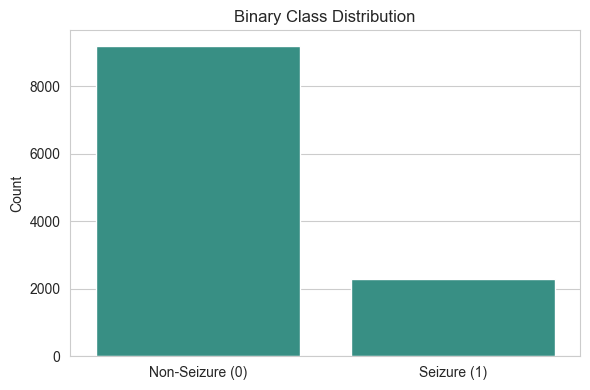


[RUBRIC] Data Visualization: Feature Histograms


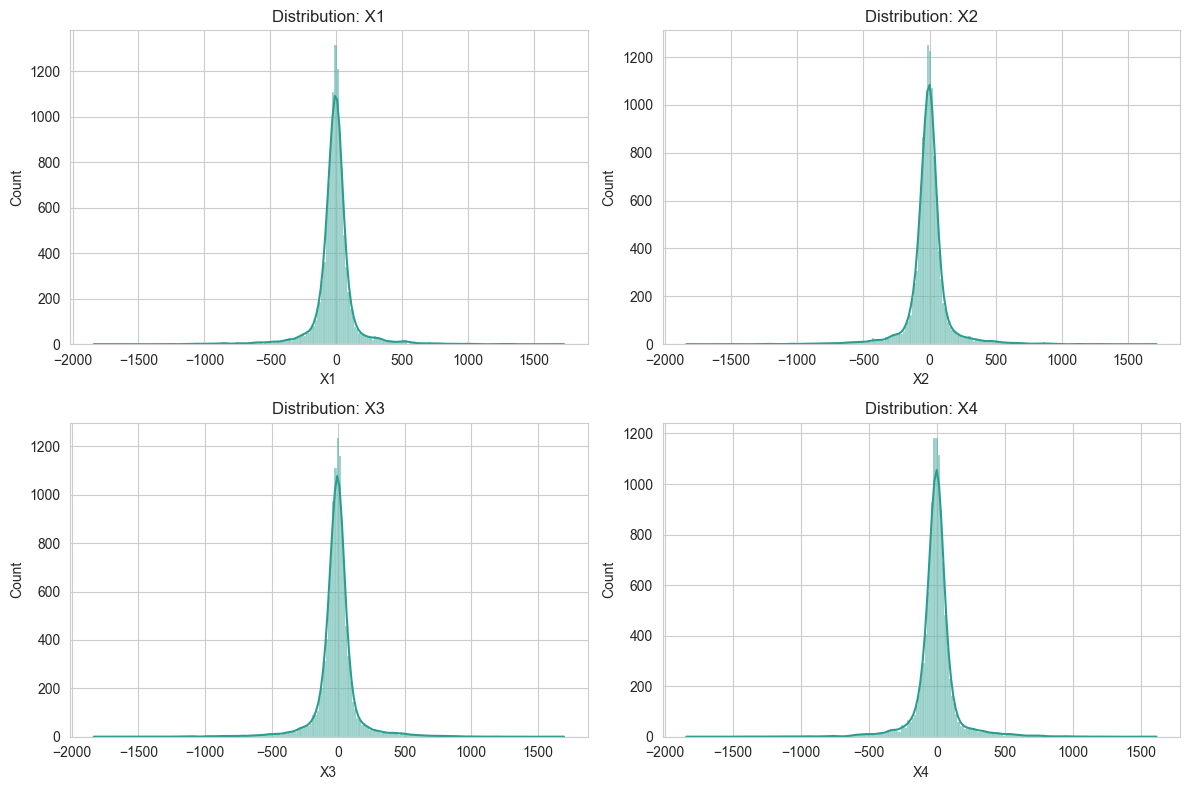


[RUBRIC] Binning Process
Binning feature: X1
X1
Low       3853
Medium    3850
High      3797
Name: count, dtype: int64


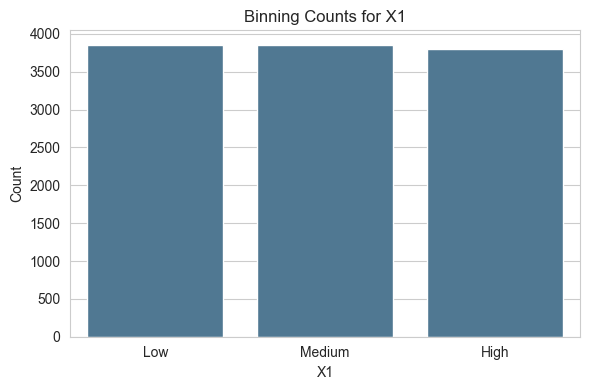


[RUBRIC] Descriptive Statistics
      min   max       mean      variance         std  skewness   kurtosis
X1  -1839  1726 -11.581391  27432.065990  165.626284 -0.454057  19.070005
X2  -1838  1713 -10.911565  27575.793814  166.059609 -0.431750  18.301298
X3  -1835  1697 -10.187130  26740.202217  163.524317 -0.603564  18.411230
X4  -1845  1612  -9.143043  26007.703600  161.269041 -0.549323  18.385460
X5  -1791  1518  -8.009739  25920.358197  160.998007 -0.304055  17.745843
X6  -1757  1816  -7.003478  26026.957462  161.328725 -0.016953  18.385049
X7  -1832  2047  -6.502087  26071.862331  161.467837  0.121392  19.155514
X8  -1778  2047  -6.687130  26282.608948  162.119120 -0.170715  20.731518
X9  -1840  2047  -6.558000  26254.809837  162.033360 -0.455410  22.811218
X10 -1867  2047  -6.168435  25739.823006  160.436352 -0.093907  20.167636
X11 -1765  2047  -5.827478  25750.947362  160.471017  0.301544  17.694048
X12 -1803  2047  -6.042174  25979.352861  161.181118  0.196914  17.377351

[RUB

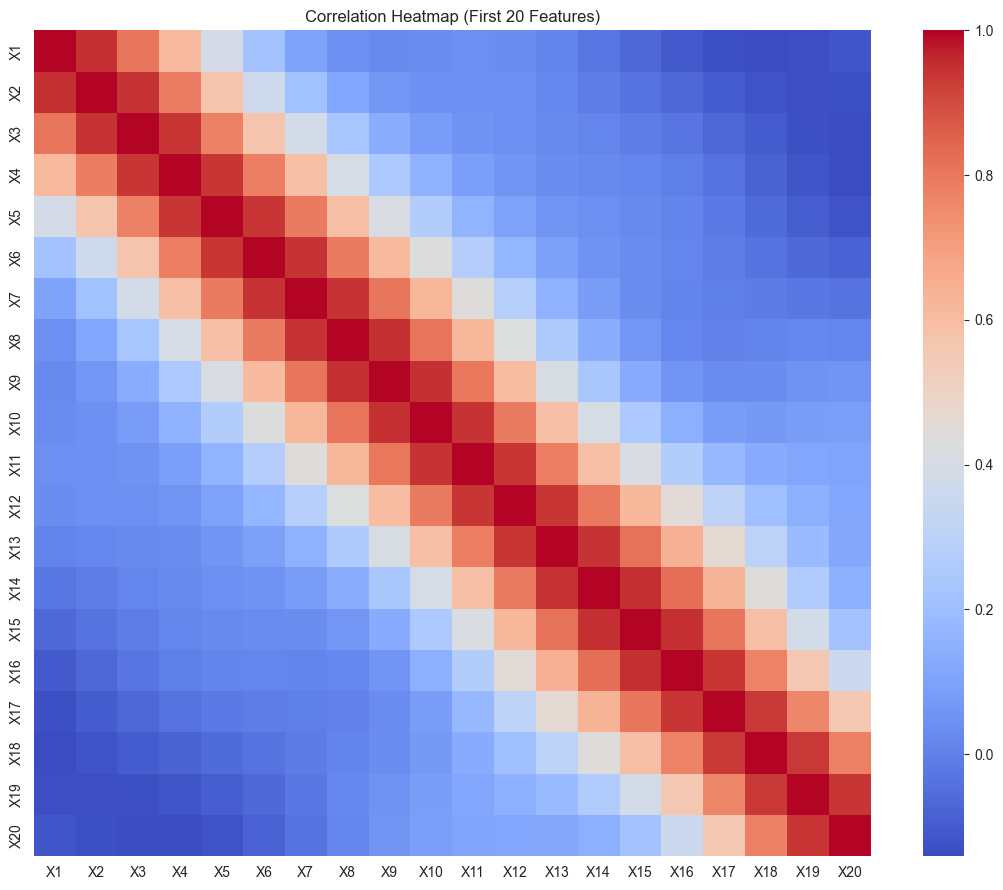


[RUBRIC] Statistical Tests: Chi-square, t-test, ANOVA
Top 10 Chi-square features:
    feature  chi2_stat  chi2_p_value
10      X11   0.141205      0.707086
158    X159   0.136836      0.711447
157    X158   0.127696      0.720833
43      X44   0.119753      0.729302
42      X43   0.119574      0.729497
159    X160   0.117928      0.731293
11      X12   0.115036      0.734482
9       X10   0.113307      0.736410
8        X9   0.090031      0.764138
94      X95   0.089271      0.765106
Top 10 t-test features:
    feature    t_stat  t_p_value
10      X11 -3.265185   0.001110
9       X10 -3.051501   0.002302
11      X12 -2.975017   0.002960
43      X44 -2.862979   0.004234
157    X158 -2.811396   0.004974
158    X159 -2.762349   0.005784
8        X9 -2.662833   0.007801
42      X43 -2.656963   0.007938
159    X160 -2.639976   0.008346
7        X8 -2.516581   0.011916
Top 10 ANOVA features:
    feature     f_stat  anova_p_value
10      X11  36.886894   1.291396e-09
9       X10  32.148024  

KeyboardInterrupt: 

In [27]:
models_now = list(build_model_registry().keys())
print("Configured models:")
for m in models_now:
    print("-", m)

outputs = run_phase1_pipeline(show_plots=True)


## Execution Complete
- Review the summary, model comparison table, and charts.
- Fill the related-work placeholders with real references before submission.
